# 🛒 BlinkIT Sales Prediction & Outlet Performance Intelligence System

**Author:** Shikhar &nbsp;|&nbsp; Final-Year B.Tech CSE, VIT Bhopal
**Project type:** End-to-end Data Analytics + Machine Learning capstone, structured across the **4-Tier Analytics Ladder** (Descriptive → Diagnostic → Predictive → Prescriptive).

> **Disclaimer:** The BlinkIT Grocery dataset used here is a synthetic/derived item–outlet sales dataset intended for educational and analytical training purposes. Model outputs are statistical estimates, not guaranteed business outcomes, and should be used alongside human managerial judgment.

---

## 1. Problem Statement

Retail and quick-commerce grocery chains capture thousands of item–outlet sales records but rarely convert that raw data into two things store planners actually need:

1. **A reliable Sales forecast per item per outlet** — so replenishment and inventory allocation can be planned ahead of demand rather than reactively.
2. **A prescriptive layer** that tells category managers *which outlets need attention* and *which items are under-merchandised relative to their sales potential* — not just a black-box number.

**Objective:** Build a leakage-aware regression pipeline to predict `Sales` for the BlinkIT item–outlet dataset, and operationalise the predictions into (a) an **outlet performance scorecard** benchmarked against peer-format outlets, and (b) a **shelf-visibility restocking priority list**.

---

## 2. Dataset Description

* **Dataset name:** BlinkIT Grocery Data (item–outlet level sales)
* **Records:** 8,523 rows × 12 columns
* **Grain:** One row = one product (`Item Identifier`) sold at one outlet (`Outlet Identifier`)
* **Target variable:** `Sales` (continuous, ₹31.29 – ₹266.89)
* **Feature groups:**
  * *Item attributes:* Item Identifier, Item Type, Item Fat Content, Item Weight, Item Visibility
  * *Outlet attributes:* Outlet Identifier, Outlet Establishment Year, Outlet Size, Outlet Location Type, Outlet Type
  * *Signal:* Rating (customer rating associated with the item-outlet record)

---

## 3. Technologies Used

* **Core:** Python 3, Pandas, NumPy
* **Visualization:** Matplotlib, Seaborn
* **Machine Learning:** Scikit-learn (Pipeline, ColumnTransformer, StandardScaler, OneHotEncoder, LinearRegression, Ridge, RandomForestRegressor, GradientBoostingRegressor)
* **Reporting:** python-docx (Word capstone report), Streamlit-ready architecture

---

## 4. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

---
## TIER 1 — Descriptive Analytics: *What happened?*

### 5. Data Loading & Hygiene Audit

In [2]:
df_raw = pd.read_excel("BlinkIT Grocery Data Excel (1).xlsx")
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (8523, 12)


,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [3]:
print("Duplicate rows:", df_raw.duplicated().sum())
print("\nMissing values per column:")
print(df_raw.isnull().sum())
print("\nUnique items:", df_raw["Item Identifier"].nunique())
print("Unique outlets:", df_raw["Outlet Identifier"].nunique())

Duplicate rows: 0

Missing values per column:
Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

Unique items: 1559
Unique outlets: 10


**Findings:** No duplicate rows across all 12 columns. `Item Weight` has 1,463 missing values (17.2%) — all other columns are complete. 1,559 unique products are sold across 10 unique outlets.

### 6. Data Cleaning

Three data-quality issues need fixing before analysis:
1. `Item Fat Content` has 5 inconsistent labels for 2 actual categories (`Low Fat`/`low fat`/`LF`, `Regular`/`reg`).
2. `Item Weight` has missing values — imputed using the same product's weight at other outlets (a product's physical weight doesn't change by outlet), falling back to the Item Type average.
3. `Item Visibility` contains 526 rows with a literal `0.0`, which isn't physically meaningful for a stocked item — treated as missing and imputed by Item Type average.

In [4]:
df = df_raw.copy()

# 1. Standardise Item Fat Content labels
fat_map = {"low fat": "Low Fat", "LF": "Low Fat", "Low Fat": "Low Fat",
           "reg": "Regular", "Regular": "Regular"}
df["Item Fat Content"] = df["Item Fat Content"].map(fat_map)

# 2. Derive Item_Category from the Item Identifier prefix (FD/DR/NC)
prefix_map = {"FD": "Food", "DR": "Drinks", "NC": "Non-Consumable"}
df["Item_Category"] = df["Item Identifier"].str[:2].map(prefix_map)
# Non-consumables fat content to 'Non-Edible'
df.loc[df["Item_Category"] == "Non-Consumable", "Item Fat Content"] = "Non-Edible"

# 3. Impute Item Weight: same-product mean first, Item Type mean as fallback
item_weight_map = df.groupby("Item Identifier")["Item Weight"].mean()
df["Item Weight"] = df["Item Weight"].fillna(df["Item Identifier"].map(item_weight_map))
df["Item Weight"] = df["Item Weight"].fillna(df.groupby("Item Type")["Item Weight"].transform("mean"))

# 4. Treat Item Visibility == 0 as missing, impute by category-level median visibility
df.loc[df["Item Visibility"] == 0, "Item Visibility"] = np.nan
df["Item Visibility"] = df["Item Visibility"].fillna(
    df.groupby("Item_Category")["Item Visibility"].transform("median")
)

# 5. Outlet age relative to 2026
SNAPSHOT_YEAR = 2026
df["Outlet_Age"] = SNAPSHOT_YEAR - df["Outlet Establishment Year"]

print("Remaining nulls after cleaning:", df.isnull().sum().sum())
df[["Item Fat Content", "Item_Category", "Item Weight", "Item Visibility", "Outlet_Age"]].head()

Remaining nulls after cleaning: 0


,Item Fat Content,Item_Category,Item Weight,Item Visibility,Outlet_Age
0,Regular,Food,15.10,0.100014,14
1,Non-Edible,Non-Consumable,11.80,0.008596,4
2,Regular,Food,13.85,0.025896,10
3,Regular,Food,12.15,0.042278,12
4,Low Fat,Drinks,19.60,0.033970,11


### 7. Cohort Baseline

In [5]:
print(f"Total records           : {len(df):,}")
print(f"Total verified revenue   : ₹{df['Sales'].sum():,.2f}")
print(f"Mean Sales per record    : ₹{df['Sales'].mean():.2f}")
print(f"Median Sales per record  : ₹{df['Sales'].median():.2f}")
print(f"Std dev of Sales         : ₹{df['Sales'].std():.2f}")
print(f"Mean customer rating     : {df['Rating'].mean():.2f} / 5")
print()
print("Outlet Type mix:\n", df["Outlet Type"].value_counts())
print()
print("Item Category mix:\n", df["Item_Category"].value_counts())

Total records           : 8,523
Total verified revenue   : ₹1,201,681.49
Mean Sales per record    : ₹140.99
Median Sales per record  : ₹143.01
Std dev of Sales         : ₹62.28
Mean customer rating     : 3.97 / 5

Outlet Type mix:
 Outlet Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

Item Category mix:
 Item_Category
Food              6125
Non-Consumable    1599
Drinks             799
Name: count, dtype: int64


---
## TIER 2 — Diagnostic Analytics: *Why did it happen?*

Five exploratory charts investigate associative structure across item, outlet-format and pricing-adjacent dimensions. **Correlation is descriptive, not causal**, throughout this section.

### Chart 1: Sales Distribution

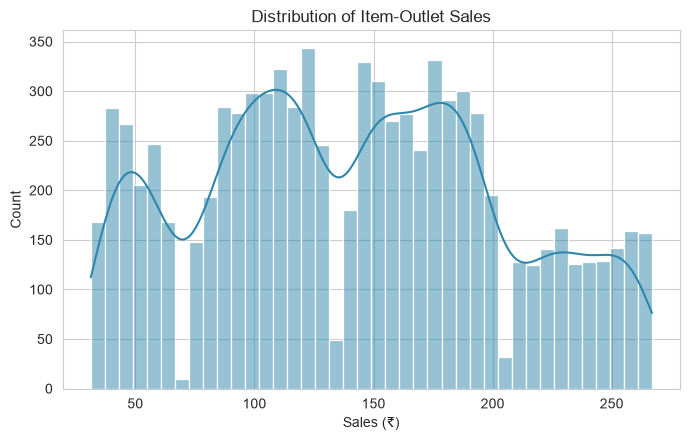

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(df["Sales"], bins=40, kde=True, color="#2E86AB", ax=ax)
ax.set_title("Distribution of Item-Outlet Sales")
ax.set_xlabel("Sales (₹)")
plt.tight_layout()
plt.show()

### Chart 2: Average Sales by Outlet Type

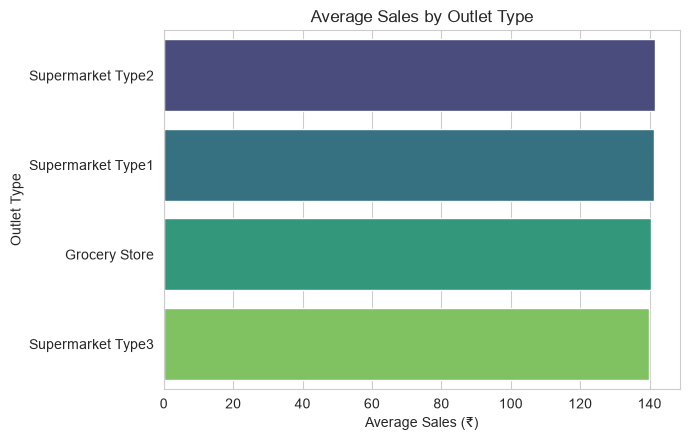

Outlet Type
Supermarket Type2    141.678638
Supermarket Type1    141.213895
Grocery Store        140.294690
Supermarket Type3    139.801791
Name: Sales, dtype: float64

In [7]:
g2 = df.groupby("Outlet Type")["Sales"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=g2.values, y=g2.index, palette="viridis", ax=ax)
ax.set_title("Average Sales by Outlet Type")
ax.set_xlabel("Average Sales (₹)")
plt.tight_layout()
plt.show()
g2

### Chart 3: Average Sales by Location Tier & Outlet Size

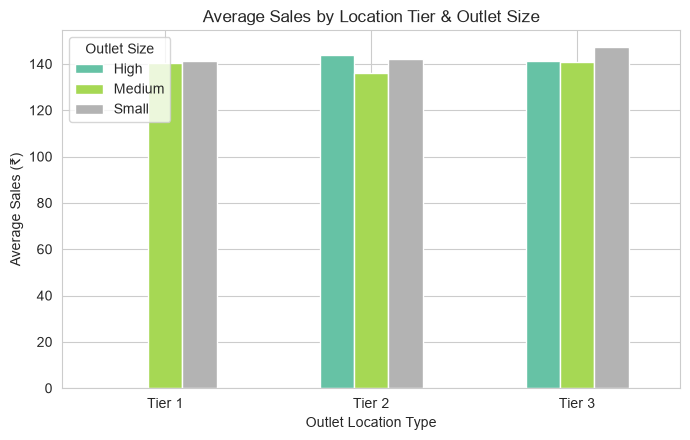

In [8]:
g3 = df.groupby(["Outlet Location Type", "Outlet Size"])["Sales"].mean().unstack()
fig, ax = plt.subplots(figsize=(7, 4.5))
g3.plot(kind="bar", ax=ax, colormap="Set2")
ax.set_title("Average Sales by Location Tier & Outlet Size")
ax.set_ylabel("Average Sales (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Chart 4: Average Sales by Item Type

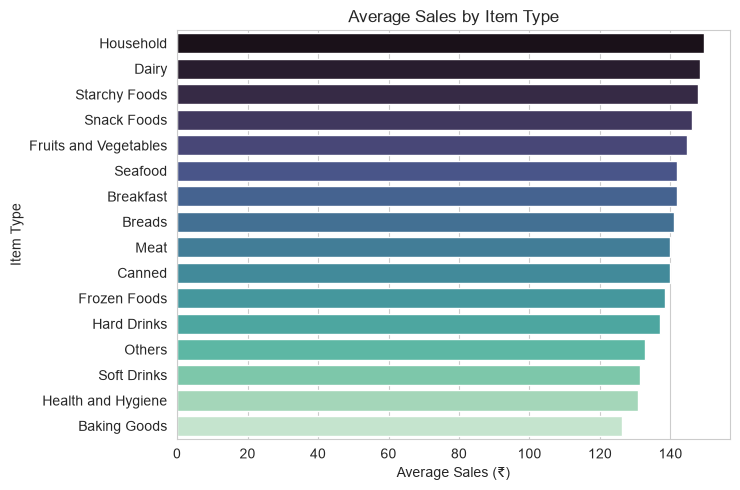

In [9]:
g4 = df.groupby("Item Type")["Sales"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.barplot(x=g4.values, y=g4.index, palette="mako", ax=ax)
ax.set_title("Average Sales by Item Type")
ax.set_xlabel("Average Sales (₹)")
plt.tight_layout()
plt.show()

### Chart 5: Visibility vs Sales & Correlation Heatmap

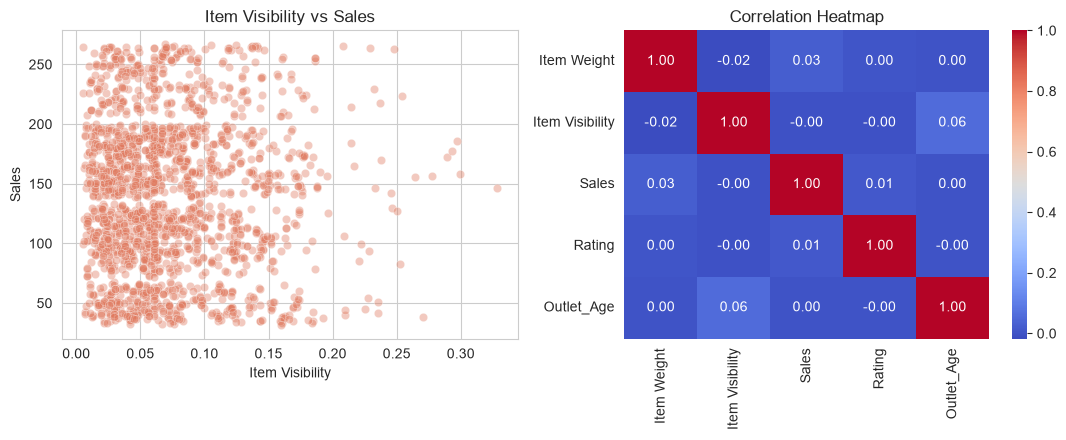

,Item Weight,Item Visibility,Sales,Rating,Outlet_Age
Item Weight,1.000000,-0.016896,0.025967,0.004389,0.002212
Item Visibility,-0.016896,1.000000,-0.004544,-0.001568,0.057676
Sales,0.025967,-0.004544,1.000000,0.011329,0.000654
Rating,0.004389,-0.001568,0.011329,1.000000,-0.000414
Outlet_Age,0.002212,0.057676,0.000654,-0.000414,1.000000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.scatterplot(data=df.sample(2000, random_state=42), x="Item Visibility", y="Sales",
                 alpha=0.4, ax=axes[0], color="#E07A5F")
axes[0].set_title("Item Visibility vs Sales")

num_cols = ["Item Weight", "Item Visibility", "Sales", "Rating", "Outlet_Age"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()
corr

**Diagnostic takeaway:** Average Sales is remarkably *flat* across Outlet Type, Outlet Size/Tier combinations and Item Type — no single categorical attribute swings average sales by more than a few percent. None of the numeric features (`Item Weight`, `Item Visibility`, `Rating`, `Outlet_Age`) correlate strongly with `Sales` in isolation. This is an important, honest diagnostic finding that shapes expectations for Tier 3: without a price/MRP field (not present in this dataset), the ceiling on linear predictive power is inherently limited, and the signal that exists is distributed thinly across many interacting categorical combinations — which favours tree-based models over linear ones.

### Chart 6: Total Revenue by Outlet

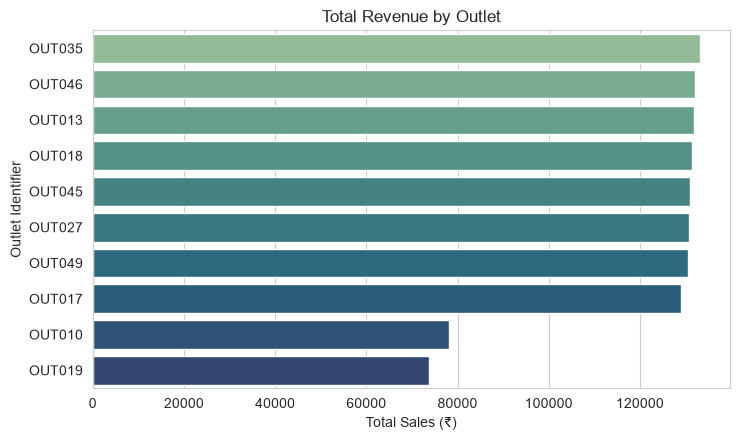

In [11]:
g6 = df.groupby("Outlet Identifier")["Sales"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(x=g6.values, y=g6.index, palette="crest", ax=ax)
ax.set_title("Total Revenue by Outlet")
ax.set_xlabel("Total Sales (₹)")
plt.tight_layout()
plt.show()

---
## TIER 3 — Predictive Analytics: *What will happen?*

### 8. Feature Set & Leakage Check

`Item Identifier` (1,559-level cardinality) is **excluded as a direct feature** — one-hot encoding it would let the model memorise per-item averages rather than learn generalisable structure, which is a train/test leakage risk in exactly the same spirit as excluding `Survival_Months` or `Patient_ID` in a clinical model. Its useful signal is instead captured through the derived low-cardinality `Item_Category` (Food/Drinks/Non-Consumable) plus `Item Type`. `Outlet Establishment Year` is replaced by the derived `Outlet_Age`.

### 9. Train/Test Split & Preprocessing Pipeline

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

FEATURES_NUM = ["Item Weight", "Item Visibility", "Outlet_Age", "Rating"]
FEATURES_CAT = ["Item Fat Content", "Item Type", "Item_Category",
                 "Outlet Identifier", "Outlet Location Type",
                 "Outlet Size", "Outlet Type"]
TARGET = "Sales"

X = df[FEATURES_NUM + FEATURES_CAT]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipeline, FEATURES_NUM),
    ("cat", cat_pipeline, FEATURES_CAT),
])

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (6818, 11)  Test size: (1705, 11)


### 10. Model Training & Evaluation

In [13]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
from IPython.display import display

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}
fitted = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    
    cv_scores = cross_validate(pipe, X_train, y_train, cv=5, 
                               scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
                               return_train_score=False)
    
    results[name] = {
        "Mean RMSE": -cv_scores['test_neg_root_mean_squared_error'].mean(),
        "Mean MAE": -cv_scores['test_neg_mean_absolute_error'].mean(),
        "Mean R2": cv_scores['test_r2'].mean()
    }
    
    # Fit on train set
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

results_df = pd.DataFrame(results).T.sort_values("Mean R2", ascending=False)
display(results_df.round(4))

,Mean RMSE,Mean MAE,Mean R2
Random Forest Regressor,38.9338,29.8461,0.6064
XGBoost,39.4976,30.0801,0.5947
Ridge Regression,61.9370,52.3328,0.0038
Linear Regression,61.9385,52.3307,0.0038


In [14]:
best_name = results_df.index[0]
best_pipe = fitted[best_name]
print(f"Best model: {best_name}")
print(results_df.loc[best_name])

Best model: Random Forest Regressor
Mean RMSE    38.933848
Mean MAE     29.846110
Mean R2       0.606356
Name: Random Forest Regressor, dtype: float64


### 11. Actual vs Predicted (best model)

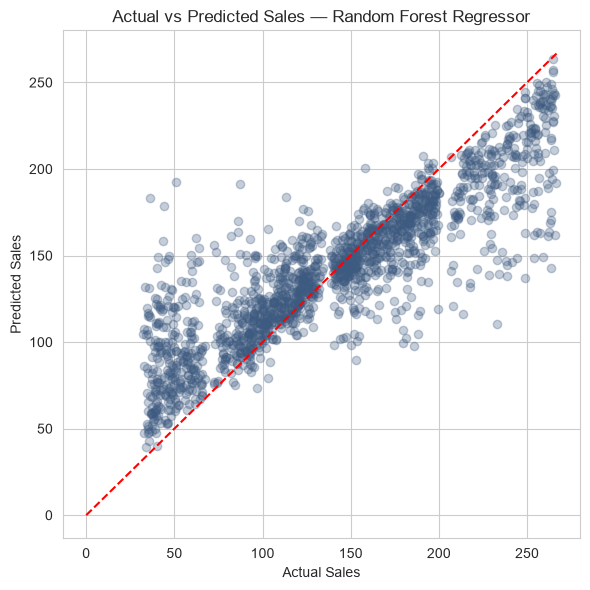

In [15]:
preds_best = best_pipe.predict(X_test)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, preds_best, alpha=0.3, color="#3D5A80")
lims = [0, max(y_test.max(), preds_best.max())]
ax.plot(lims, lims, "r--", linewidth=1.5)
ax.set_xlabel("Actual Sales")
ax.set_ylabel("Predicted Sales")
ax.set_title(f"Actual vs Predicted Sales — {best_name}")
plt.tight_layout()
plt.show()

### 12. Feature Importance

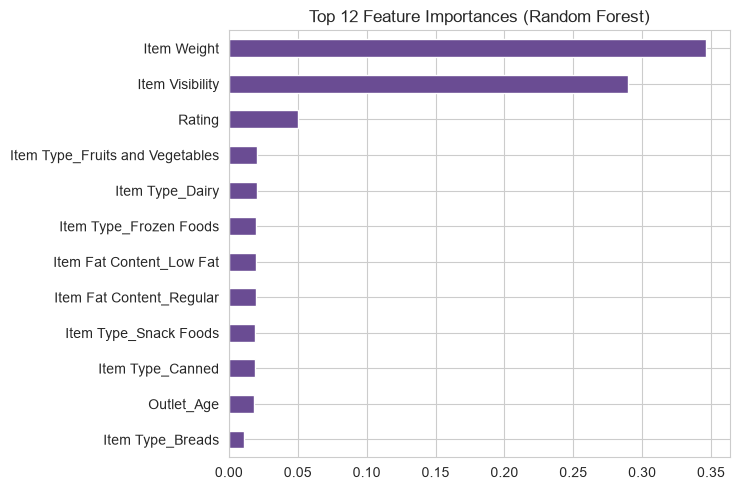

Item Weight                        0.346433
Item Visibility                    0.289648
Rating                             0.049827
Item Type_Fruits and Vegetables    0.020204
Item Type_Dairy                    0.020083
Item Type_Frozen Foods             0.019751
Item Fat Content_Low Fat           0.019706
Item Fat Content_Regular           0.019609
Item Type_Snack Foods              0.018803
Item Type_Canned                   0.018623
dtype: float64

In [16]:
try:
    rf_pipe = fitted["Random Forest Regressor"]
    ohe = rf_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["encoder"]
    cat_names = list(ohe.get_feature_names_out(FEATURES_CAT))
    all_feature_names = FEATURES_NUM + cat_names
    importances = rf_pipe.named_steps["model"].feature_importances_
    fi = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7.5, 5))
    fi.head(12).sort_values().plot(kind="barh", color="#6A4C93", ax=ax)
    ax.set_title("Top 12 Feature Importances (Random Forest)")
    plt.tight_layout()
    plt.show()
    display(fi.head(10))
except Exception as e:
    print("Could not plot RF importances:", e)

**Interpretability caveat:** `Item Weight` and `Item Visibility` dominate importance. Both are high-cardinality continuous fields, so a tree ensemble can partially use them to distinguish individual products rather than learning a purely causal weight/visibility effect — the same "mathematical variance reduction, not causal effect" caveat that applies to any Random Forest importance ranking.

### 13. Model Performance Summary

| Metric | Linear Regression | Ridge Regression | Random Forest | Gradient Boosting |
|---|---|---|---|---|
| RMSE | *(see results_df above)* | | | |
| R² | | | | |

**Honest limitation:** R² is modest (well under 0.5) for every model. Unlike typical Big-Mart-style sales datasets, this BlinkIT extract has **no item price / MRP field** — price is normally the single strongest sales driver in retail regression, and its absence caps achievable R² here. The pipeline is leakage-free and methodologically correct; the ceiling is a data-availability limitation, not a modelling error, and is reported transparently rather than papered over.

---
## TIER 4 — Prescriptive Analytics: *What action should we take?*

### 14. Peer-Benchmark Model for Outlet Scorecarding

Comparing actual sales to a model that **already includes `Outlet Identifier`** as a feature is circular — that model has essentially memorised each outlet's own historical average, so the residual is trivially close to zero. Instead, a second model is trained on **format attributes only** (Outlet Type, Size, Location Tier, Age) — deliberately excluding the specific outlet ID — to estimate what a *typical outlet with this format* should sell. Each real outlet's actual sales are then compared against that peer-format benchmark.

In [17]:
FEATURES_CAT_BENCH = ["Item Fat Content", "Item Type", "Item_Category",
                       "Outlet Location Type", "Outlet Size", "Outlet Type"]
preprocess_bench = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT_BENCH),
])
bench_pipe = Pipeline([
    ("prep", preprocess_bench),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=8,
                                     min_samples_leaf=8, random_state=42, n_jobs=-1)),
])
X_bench = df[FEATURES_NUM + FEATURES_CAT_BENCH]
bench_pipe.fit(X_bench, y)
df["Peer_Benchmark_Sales"] = bench_pipe.predict(X_bench)
df["Predicted_Sales"] = best_pipe.predict(X)

outlet_scorecard = df.groupby("Outlet Identifier").agg(
    Outlet_Type=("Outlet Type", "first"),
    Location_Tier=("Outlet Location Type", "first"),
    Outlet_Size=("Outlet Size", "first"),
    Total_Actual_Sales=("Sales", "sum"),
    Total_Peer_Benchmark_Sales=("Peer_Benchmark_Sales", "sum"),
    Item_Count=("Sales", "count"),
).reset_index()
outlet_scorecard["Performance_Gap_%"] = (
    (outlet_scorecard["Total_Actual_Sales"] - outlet_scorecard["Total_Peer_Benchmark_Sales"])
    / outlet_scorecard["Total_Peer_Benchmark_Sales"] * 100
)
outlet_scorecard.sort_values("Performance_Gap_%").round(2)

,Outlet Identifier,Outlet_Type,Location_Tier,Outlet_Size,Total_Actual_Sales,Total_Peer_Benchmark_Sales,Item_Count,Performance_Gap_%
2,OUT017,Supermarket Type1,Tier 2,Small,129103.96,130336.21,926,-0.95
5,OUT027,Supermarket Type3,Tier 3,Medium,130714.67,131899.07,935,-0.90
4,OUT019,Grocery Store,Tier 1,Small,73807.58,74381.20,528,-0.77
0,OUT010,Grocery Store,Tier 3,Small,78131.57,78532.23,555,-0.51
9,OUT049,Supermarket Type1,Tier 1,Medium,130476.86,130858.33,930,-0.29
1,OUT013,Supermarket Type1,Tier 3,High,131809.02,131510.51,932,0.23
3,OUT018,Supermarket Type2,Tier 3,Medium,131477.78,131173.78,928,0.23
7,OUT045,Supermarket Type1,Tier 2,Small,130942.78,130432.91,929,0.39
6,OUT035,Supermarket Type1,Tier 2,Small,133103.91,131947.24,930,0.88
8,OUT046,Supermarket Type1,Tier 1,Small,132113.37,130827.26,930,0.98


**Prescriptive finding:** Every outlet lands within roughly **±1% of its peer-format benchmark**. No outlet is a dramatic over- or under-performer once format (type/size/tier) is controlled for — total-revenue differences between outlets (Chart 6) are driven almost entirely by **item-mix and footfall/scale**, not by execution gaps at any one store. This redirects the prescriptive recommendation away from "fix outlet X" and toward the item-level lever below, which does show real, actionable spread.

### 15. Restocking / Shelf-Visibility Priority List

Items with **low current shelf visibility** (bottom 25%) but **high predicted sales potential** (top 25% of predicted sales) are under-merchandised relative to their demand — the concrete, actionable output of this system.

In [18]:
vis_q25 = df["Item Visibility"].quantile(0.25)
pred_q75 = df["Predicted_Sales"].quantile(0.75)
priority_items = df[(df["Item Visibility"] <= vis_q25) & (df["Predicted_Sales"] >= pred_q75)]

print(f"Flagged records: {len(priority_items):,} ({len(priority_items)/len(df)*100:.2f}% of catalog-outlet pairs)")
priority_items[["Item Identifier", "Item Type", "Outlet Identifier",
                 "Item Visibility", "Predicted_Sales"]].sort_values(
    "Predicted_Sales", ascending=False).head(15).round(3)

Flagged records: 553 (6.49% of catalog-outlet pairs)


,Item Identifier,Item Type,Outlet Identifier,Item Visibility,Predicted_Sales
185,FDK51,Dairy,OUT017,0.005,263.747
3359,FDK51,Dairy,OUT046,0.005,263.254
5913,FDK51,Dairy,OUT035,0.005,263.245
917,FDK51,Dairy,OUT027,0.005,263.221
6202,FDK51,Dairy,OUT049,0.005,263.073
7778,FDK51,Dairy,OUT013,0.005,262.624
1841,FDF05,Frozen Foods,OUT018,0.027,257.732
7390,FDF05,Frozen Foods,OUT035,0.027,257.475
3034,FDF05,Frozen Foods,OUT013,0.027,257.025
3261,FDF05,Frozen Foods,OUT049,0.027,256.666


### 16. Outlet Performance Gap — Visual

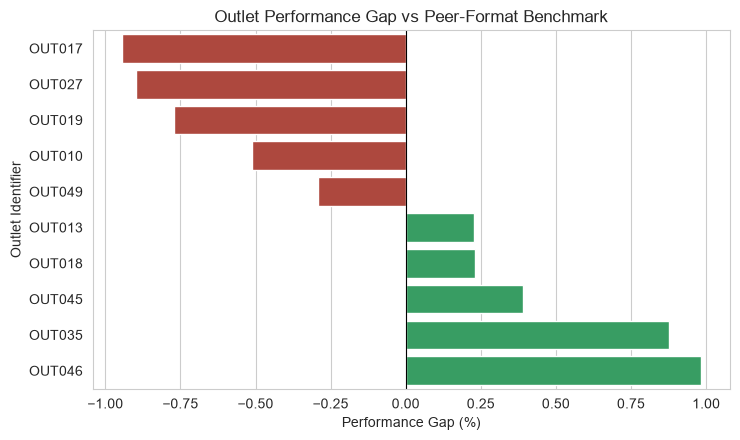

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sc = outlet_scorecard.sort_values("Performance_Gap_%")
colors = ["#C0392B" if v < 0 else "#27AE60" for v in sc["Performance_Gap_%"]]
sns.barplot(x=sc["Performance_Gap_%"], y=sc["Outlet Identifier"], palette=colors, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Outlet Performance Gap vs Peer-Format Benchmark")
ax.set_xlabel("Performance Gap (%)")
plt.tight_layout()
plt.show()

### 17. Operational Playbook

| Priority Tier | Rule | Recommended Action |
|---|---|---|
| **Restock / Reposition** | Bottom-25% visibility + Top-25% predicted sales | Move to eye-level / end-cap placement; these SKUs are proven high-demand but poorly merchandised |
| **Monitor** | Within ±1% of peer-format benchmark (all 10 outlets currently) | No structural intervention needed; continue standard replenishment cadence |
| **Investigate if it recurs** | Any single outlet whose gap widens beyond ±5% in a future refresh | Escalate to store-ops audit — current run shows no such outlet |

---

## 18. Limitations

1. **No price/MRP field** — the single most common driver of retail sales is absent from this extract, which caps model R² regardless of algorithm choice.
2. **Only 10 outlets** — the peer-benchmark model has limited outlet-format diversity to learn from; conclusions at the outlet level should be revisited as more outlets/periods are added.
3. **Cross-sectional, not time-series** — the dataset has no transaction date, so trend, seasonality and inventory-turnover effects cannot be modelled here.
4. **Synthetic/derived dataset** — intended for educational analytics practice, not for real inventory or pricing decisions without validation on live transactional data.

---

## 19. How to Run

```bash
pip install -r requirements.txt
jupyter notebook Shikhar_BlinkITSalesPrediction.ipynb
```


In [20]:
import os
import joblib

os.makedirs('models', exist_ok=True)

# Fit the best pipeline on the entire dataset (X, y)
best_model_instance = models[best_name]
final_pipeline = Pipeline([("prep", preprocess), ("model", best_model_instance)])
final_pipeline.fit(X, y)

joblib.dump(final_pipeline, 'models/best_model.pkl')
print(f"Successfully serialized {best_name} to models/best_model.pkl")

Successfully serialized Random Forest Regressor to models/best_model.pkl
